In [1]:
from networks.BP_network import *
from networks.DFC_network import *
from src.dataloaders import *
from src.trainers import Trainer, TrainerDFCL, TrainerDFCGen, TrainerCL, TrainerCL_DFC
from src.utils import *

/cluster/raid/home/sschwartz/.conda/envs/DFC_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
config = {
        "layers": [784, 200, 10],
        "num_classes": 10,
        "lr": 1e-4, 
        "lr_fb": 1e-4, 
        "batch_size": 100,
        "batch_size_gen": 30000,
        "epochs": 50,
        "mode": "di",
        "num_workers": 0,
        "loss_fn": "ce",
        "optimizer": "Adam",
        "scheduler": "CosineAnnealingLR",
        "activation_fun": "Tanh",
        "device": "cuda",
        "output_dir": "./outputs",
        "seed": 1337,
        "taus": [0.02, 0.02, 0.02, 0.016, 0.01],
        "target_lr": 1,#1e-2,       # Updated to optimal value
        "alpha_di": 0.0017,        # 1/tau for tau=0.2
        "dt_di": 0.02,         # Time step
        "time_constant_ratio": 0.2,  # tau
        "tmax_di":2,
        "k_p": 2.0,             # Optimal for G=1, tau=0.2
        "eps": 1e-4,
        "save": True,
        "flatten_imgs": "default",
        "num_tasks": 2,
        "classes_per_task": 5,
        "setting": "classIL5task",
}

config = dotdict(config)

In [3]:
tasks_dataloaders = ClassILMNIST2Task(config=config).get_all_tasks_dataloaders()

In [8]:
# Train model
model = DFCL_network(config=config)

trainer = TrainerCL_DFC(model, tasks_dataloaders, config)
trainer.train()

[DFCL] Feedback connections initialized.
Training:
 - layers: [784, 200, 10]
 - num_classes: 10
 - lr: 0.0001
 - lr_fb: 0.0001
 - batch_size: 100
 - batch_size_gen: 30000
 - epochs: 50
 - mode: di
 - num_workers: 0
 - loss_fn: ce
 - optimizer: Adam
 - scheduler: CosineAnnealingLR
 - activation_fun: Tanh
 - device: cuda
 - output_dir: ./outputs
 - seed: 1337
 - taus: [0.02, 0.02, 0.02, 0.016, 0.01]
 - target_lr: 1
 - alpha_di: 0.0017
 - dt_di: 0.02
 - time_constant_ratio: 0.2
 - tmax_di: 2
 - k_p: 2.0
 - eps: 0.0001
 - save: True
 - flatten_imgs: default
 - num_tasks: 2
 - classes_per_task: 5
 - setting: classIL5task
 - model: DFCL_network



[TrainerDFCL] Created optimizers: feedforward, 1× feedback.
Starting Task 1/2


Training epoch 001/50:   0%|          | 0/306 [00:00<?, ?batch/s]

				Epoch: 001, Train loss: 1.4964 & test losses: T0: 0.4502 & accuracy: T0: 90.97, Full: 90.91


				Epoch: 002, Train loss: 0.3253 & test losses: T0: 0.1776 & accuracy: T0: 95.80, Full: 95.80


...

				Epoch: 048, Train loss: 0.0051 & test losses: T0: 0.0248 & accuracy: T0: 99.18, Full: 99.18


				Epoch: 049, Train loss: 0.0047 & test losses: T0: 0.0249 & accuracy: T0: 99.24, Full: 99.24


				Epoch: 050, Train loss: 0.0045 & test losses: T0: 0.0249 & accuracy: T0: 99.22, Full: 99.22
Testing on all seen classes up to Task 1


Testing  epoch 000/50:   0%|          | 0/52 [00:00<?, ?batch/s]

Seen Classes - Loss: 0.0247, Accuracy: 99.2216


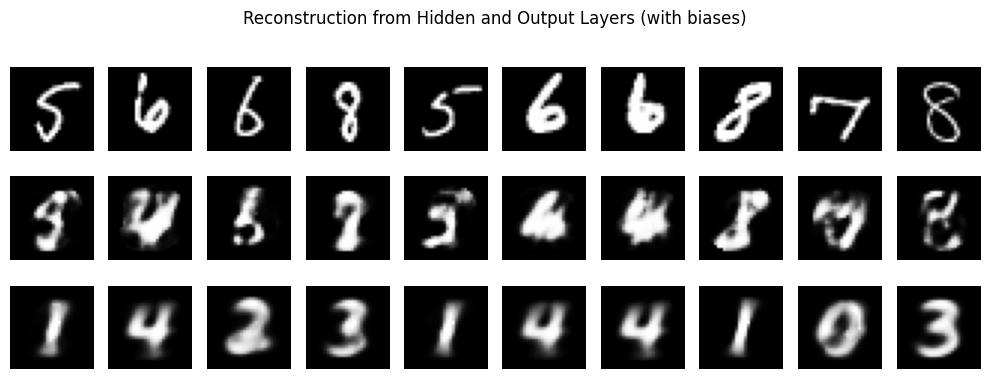

In [10]:
x1, x2, x3 = visualize_reconstructions(model, tasks_dataloaders[1][0])